In [2]:
import numpy as np
from astropy.io import fits 
import pylab as plt 


# Problem 1

#### 1.

To satisfy $\mathbb{Z}_2$-symmetry, we feed only even features into our model: 

$$  h_\theta(x) =g_\theta (x^2) $$

where $ g_\theta$ is a standard neural network (in our case a multi-layer perceptron implemented using sklearn).

Proof: $$h_\theta(-x)=g_\theta((-x)^2)=g_\theta(x^2)=h_\theta(x)$$.


#### 2.

We now sample data from the even function $f(x)=\cos(x)$:


In [3]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_squared_error
def test_z2_symmetry(x_train, y_train, x_test, y_test):
    a=(20,20,20,10,5)  # architecture
    mlp_base = MLPRegressor(hidden_layer_sizes=a, activation='relu', solver='adam', alpha=1e-4, max_iter=4000, random_state=12)
    mlp_z2 = MLPRegressor(hidden_layer_sizes=a, activation='relu', solver='adam', alpha=1e-4, max_iter=4000, random_state=2)

    # Baseline: feed x directly
    mlp_base.fit(x_train.reshape(-1, 1), y_train)

    # Z2-symmetric: feed x² to enforce symmetry around x=0
    mlp_z2.fit((x_train**2).reshape(-1, 1), y_train)

    base_pred = mlp_base.predict(x_test.reshape(-1, 1))
    z2_pred   = mlp_z2.predict((x_test**2).reshape(-1, 1))

    mse_base_full = mean_squared_error(y_test, base_pred)
    mse_z2_full   = mean_squared_error(y_test, z2_pred)
    return mse_base_full, mse_z2_full , base_pred, z2_pred

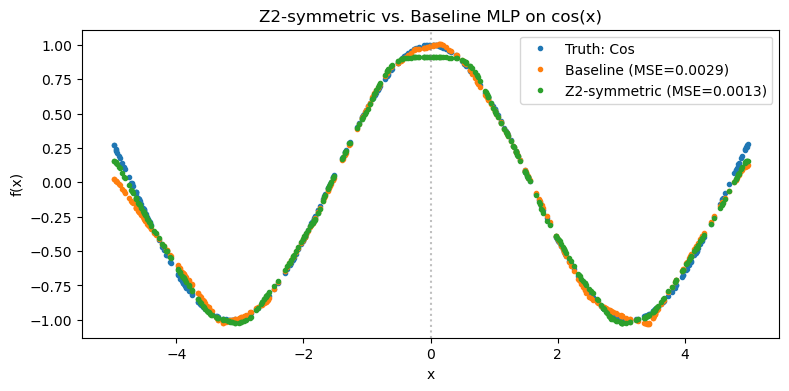

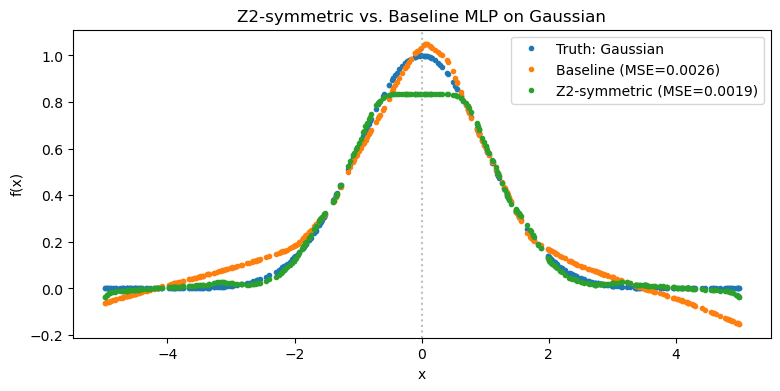

In [4]:



# Generate toy training and test data for cos(x)
rng = np.random.default_rng(42)
x_train = rng.uniform(-5, 5, 400)        
y_train = np.cos(x_train) 

x_test = rng.uniform(-5, 5, 400)
y_test = np.cos(x_test)  
mse_base_full_cos, mse_z2_full_cos, base_pred_cos, z2_pred_cos = test_z2_symmetry(x_train, y_train, x_test, y_test)



# Plot to visualize cos(x)
plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Cos')
plt.plot(x_test, base_pred_cos, '.', label=f'Baseline (MSE={mse_base_full_cos:.4f})')
plt.plot(x_test, z2_pred_cos, '.', label=f'Z2-symmetric (MSE={mse_z2_full_cos:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on cos(x)')
plt.show()

# Generate toy training and test data for a gaussian:
rng = np.random.default_rng(42)
x_train = rng.uniform(-5, 5, 400)       
y_train = np.exp(-0.5 * x_train**2)
x_test = rng.uniform(-5, 5, 400)
y_test = np.exp(-0.5 * x_test**2) 
mse_base_full_gauss, mse_z2_full_gauss, base_pred_gauss, z2_pred_gauss = test_z2_symmetry(x_train, y_train, x_test, y_test) 

plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Gaussian')
plt.plot(x_test, base_pred_gauss, '.', label=f'Baseline (MSE={mse_base_full_gauss:.4f})')
plt.plot(x_test, z2_pred_gauss, '.', label=f'Z2-symmetric (MSE={mse_z2_full_gauss:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on Gaussian')
plt.show()



For both even functions we see that by introducing the Z2-symmetry, the model performs better.  We find, interestingly, that the model has a harder time to predict the data around $x = \pm 0.5$. If we had chosen the training data to only sample from x>0, we would see the baseline model fail terribly in the region $x<0$, as we see below:

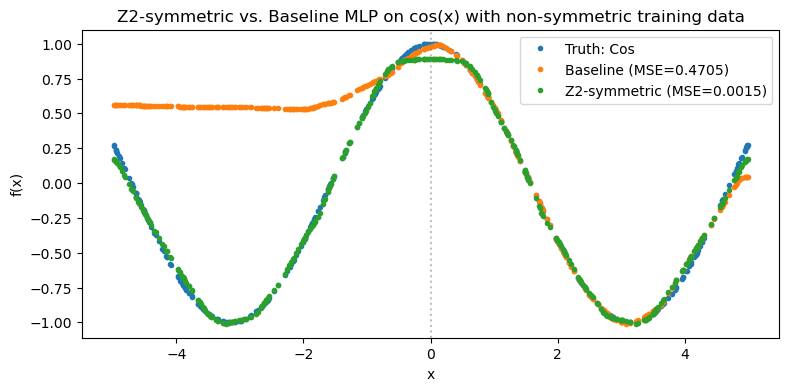

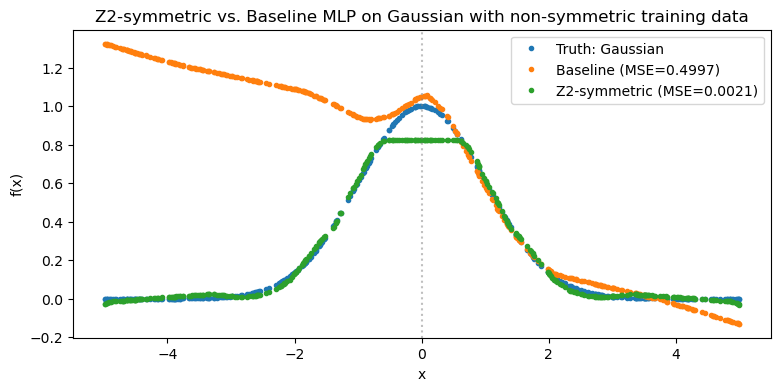

In [5]:



# Generate toy training and test data for cos(x)
rng = np.random.default_rng(42)
x_train = rng.uniform(0, 5, 400)        
y_train = np.cos(x_train) 

x_test = rng.uniform(-5, 5, 400)
y_test = np.cos(x_test)  
mse_base_full_cos, mse_z2_full_cos, base_pred_cos, z2_pred_cos = test_z2_symmetry(x_train, y_train, x_test, y_test)



# Plot to visualize cos(x)
plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Cos')
plt.plot(x_test, base_pred_cos, '.', label=f'Baseline (MSE={mse_base_full_cos:.4f})')
plt.plot(x_test, z2_pred_cos, '.', label=f'Z2-symmetric (MSE={mse_z2_full_cos:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on cos(x) with non-symmetric training data')
plt.show()

# Generate toy training and test data for a gaussian:
rng = np.random.default_rng(42)
x_train = rng.uniform(0, 5, 400)       
y_train = np.exp(-0.5 * x_train**2)
x_test = rng.uniform(-5, 5, 400)
y_test = np.exp(-0.5 * x_test**2) 
mse_base_full_gauss, mse_z2_full_gauss, base_pred_gauss, z2_pred_gauss = test_z2_symmetry(x_train, y_train, x_test, y_test) 

plt.figure(figsize=(9, 4))
plt.plot(x_test, y_test, '.', label='Truth: Gaussian')
plt.plot(x_test, base_pred_gauss, '.', label=f'Baseline (MSE={mse_base_full_gauss:.4f})')
plt.plot(x_test, z2_pred_gauss, '.', label=f'Z2-symmetric (MSE={mse_z2_full_gauss:.4f})')
plt.axvline(0, color='gray', ls=':', alpha=0.5)

plt.legend()
plt.xlabel('x'); plt.ylabel('f(x)')
plt.title('Z2-symmetric vs. Baseline MLP on Gaussian with non-symmetric training data')
plt.show()



# Problem 2

## Part 1a
The data set that we will use is a turbulent radiative layer in 2D with four scalar fields at every time step. The four fields are:
0	density
1	pressure
2	velocity_x (horizontal component)
3	velocity_y (vertical component)  

The system is brought to its initial conditions after every 100 frames.
The initial conditions are:
The density is large and uniform up to x=150 and 0 for x>150. 

Pressure is uniform throughout the space.

The Velocity in the y direction is randomized from initialisation to initialisation and so is velocity in x, except all mass in the high density region moves in negative x-direction.    

As for boundary conditions, the boundary tensor reads [[2,2],[1,1]] which is a statement that the system is open in the x-direction, while there are periodic boundary conditions in the y-direction for the density field. 
First let's import, split and visualize the data by borrowing the scripts from "Example of using TheWell.ipynb" by Clark Miyamoto:  

In [6]:
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'

In [7]:
import the_well
from the_well.data import WellDataset
from the_well.utils.download import well_download
import matplotlib.pyplot as plt

In [8]:
# Takes a long time, modify your script so you only run this once.
well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)

In [9]:
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=SPLIT,
)
print(type(dataset))

<class 'the_well.data.datasets.WellDataset'>


In [10]:
len(dataset)

7200

In [11]:
dataset[0].keys()

dict_keys(['input_fields', 'output_fields', 'constant_scalars', 'boundary_conditions', 'space_grid', 'input_time_grid', 'output_time_grid'])

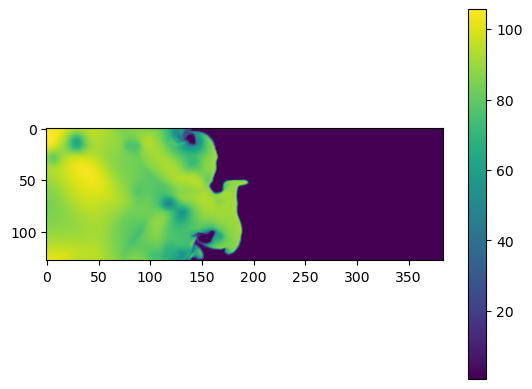

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


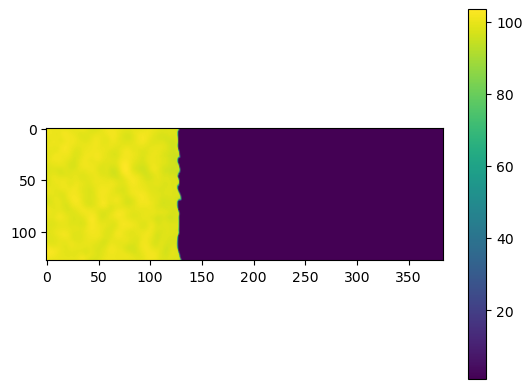

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


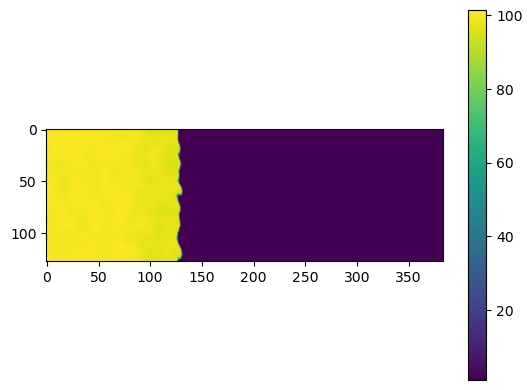

Bound. cond.:  
 tensor([[2., 2.],
        [1., 1.]])
Input fields shape: torch.Size([1, 128, 384, 4])


In [12]:
for i in range(3):
    # Add a colorbar. 
    idx = 99+i
    channel_id = 0
    plt.imshow(dataset[idx]['output_fields'][0][:,:,channel_id])
    plt.colorbar()
    plt.show()
    print('Bound. cond.:  \n '+str(dataset[idx]['boundary_conditions']))
    print('Input fields shape:', dataset[idx]['input_fields'].shape)

In [13]:
dataset[0]['boundary_conditions']

tensor([[2., 2.],
        [1., 1.]])

In [14]:
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider

def visualize_dataset(idx):
    # Retrieve the data for the selected index
    # Assuming 'input_fields' shape is (frames, height, width, channels)
    data = dataset[idx]['input_fields'][0]

    fig, ax = plt.subplots()
    im = ax.imshow(data[:, :, 0])
    ax.set_title(f"Dataset Index: {idx} | Channel: 0")

    def update(channel_id):
        # Update image data for each frame of the animation
        im.set_data(data[:, :, channel_id])
        ax.set_title(f"Dataset Index: {idx} | Channel: {channel_id}")
        return [im]

    # Create animation: frames = number of channels/time steps
    num_channels = data.shape[-1]
    ani = FuncAnimation(fig, update, frames=range(num_channels),
                        interval=200, blit=True)

    plt.show()

# Create the interactive slider
interact(visualize_dataset, idx=IntSlider(min=0, max=len(dataset)-1, step=1, value=0))

interactive(children=(IntSlider(value=0, description='idx', max=7199), Output()), _dom_classes=('widget-intera…

<function __main__.visualize_dataset(idx)>

## Part 1b

The symmetry that we will enforce is translational equivariance in the y-direction, since translating in the y-direction shouldn't change the physics. This is not the case in the x-direction, where the fields don't "wrap around". 

## Part 2a
For our architecture we have connectivity at each layer of the neural network that enforces this translational equivariance. Let's set up the network so that each layer has the same size as the input field (no pooling/striding) and that it connects to nearest neighbor (CNN), with the exception of the nodes closest to the top and bottom edge - those a connected to the bottom nodes too. In other words, in the y-direction, the convolution wraps around, while in x it uses standard zero-padding.  

## Part 2b

We now proceed to the proof (Help from Goodfellow et al. 2016, ch. 9 and LLM Model Claude):
Claim: Let $\bold{Z}_{N_y}$ be the cyclic group of order $N_y$ (the number of pixels in the y-directions), then a CNN with circular padding in y is $G$-equivariant for $G=\bold{Z}_{N_y}$ that is, $f(\rho(t_k)x)=\rho(t_k)f(x)$ for all $g=t_k \in G.$

For a shift $g$ both input and ouput representations act identically: 

$$ [\rho_{in}(t_k)x]_{i,j}=x_{i,(j-k)\mod N_y}$$
$$ \rho_{in}=\rho_{out} $$

A convulutional layer with circular padding in $y$ computes:

$$ [f(x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}x_{i+a,(j+b)\mod N_y} + \beta) $$

Here $a$ and $b$ are bounded so that we preserve connectivity to nearest neighbors and the cyclic padding is implemented through $(j+b)\mod N_y$ on the y-index. 

Proof: 
$$ [f(\rho_{in}(t_k)x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}[\rho_{in}(t_k)x]_{i+a,(j+b)\mod N_y}+\beta) $$

$$ [f(\rho_{in}(t_k)x)]_{i,j}=\sigma(\sum_{a,b}w_{a,b}x_{i+a,(j-k+b)\mod N_y}+\beta) $$

$$[f(\rho_{in}(t_k)x)]_{i,j}= [f(x)]_{i,(j−k)\mod N_y}$$

Meanwhile:

$$ [\rho_{out}(t_k)f(x)]_{i,j}=[f(x)]_{i,(j−k)\mod N_y} $$

$$\implies [\rho_{out}(t_k)f(x)]_{i,j}=[f(\rho_{in}(t_k)x)]_{i,j} \blacksquare $$


## Part 3a
We now proceed with the implementation of this translational equivariance. To prepare the data, we normalize the data so that the weights are fair accross all channels. 

In [15]:
# ALL IMPORTS, DEF. OF FUNCTIONS AND CLASSES
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from ipywidgets import interact, IntSlider
import numpy as np
from astropy.io import fits 
import pylab as plt 
# --- Custom Layers ---
class CircPadConv2d(nn.Module):
    def __init__(self, in_ch, out_ch, kernel_size=3):
        super().__init__()
        self.pad = kernel_size // 2
        self.conv = nn.Conv2d(in_ch, out_ch, kernel_size, padding=0)

    def forward(self, x):
        x = F.pad(x, (self.pad, self.pad, 0, 0), mode='constant', value=0)
        x = F.pad(x, (0, 0, self.pad, self.pad), mode='circular')
        return self.conv(x)

# --- CNN Model ---
class CircPadCNN(nn.Module):
    def __init__(self, in_ch=16, out_ch=4):
        super().__init__()
        kernel_s = 5
        self.conv1 = CircPadConv2d(in_ch, 32, kernel_size=kernel_s)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = CircPadConv2d(32, 64, kernel_size=kernel_s)
        self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = CircPadConv2d(64, 32, kernel_size=kernel_s)
        self.bn3 = nn.BatchNorm2d(32)
        self.conv4 = CircPadConv2d(32, 16, kernel_size=kernel_s)
        self.bn4 = nn.BatchNorm2d(16)
        self.conv5 = CircPadConv2d(16, out_ch, kernel_size=kernel_s)

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        x1 = F.relu(self.bn1(self.conv1(x)))
        x2 = F.relu(self.bn2(self.conv2(x1)))
        x3 = F.relu(self.bn3(self.conv3(x2)))
        x4 = F.relu(self.bn4(self.conv4(x3)))
        correction = self.conv5(x4)
        return last_frame + correction

# --- Loss ---
def gradient_loss(pred, target):
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return ((pred_dx - target_dx).abs().mean() + (pred_dy - target_dy).abs().mean())

# --- Data Preparation (memory-friendly) ---
def prepare_data(dataset, init, final, n_frames=4):
    x = []
    y = []
    for i in range(init, final - n_frames + 1):
        frames = []
        for j in range(n_frames):
            frames.append(dataset[i + j]['input_fields'][0][:, :, :].permute(2, 0, 1))
        stacked = torch.cat(frames, dim=0)
        x.append(stacked)
        y.append(dataset[i + n_frames - 1]['output_fields'][0][:, :, :].permute(2, 0, 1))
    return torch.stack(x).float(), torch.stack(y).float()

print("All classes and functions defined.")
print(f"CUDA available: {torch.cuda.is_available()}")
#if torch.cuda.is_available():
#    print(f"GPU: {torch.cuda.get_device_name(0)}")

All classes and functions defined.
CUDA available: True


In [16]:
from neuralop.models import FNO

class ResidualFNO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fno = FNO(
            n_modes=(12, 12),
            in_channels=16,
            out_channels=4,
            hidden_channels=64,
            n_layers=4,
            domain_padding=0.0,
        )

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        correction = self.fno(x)
        return last_frame + correction

print("FNO model defined.")

FNO model defined.


In [19]:
BASE_PATH = './datasets'
DATASET = 'turbulent_radiative_layer_2D'
SPLIT = 'train'
well_download(base_path=BASE_PATH, dataset=DATASET, split=SPLIT)
dataset = WellDataset(
    well_base_path='./datasets/' + BASE_PATH,
    well_dataset_name=DATASET,
    well_split_name=SPLIT,
)
print(type(dataset))



<class 'the_well.data.datasets.WellDataset'>


In [20]:
Ntrain = 300
X_train, y_train = prepare_data(dataset, 0, Ntrain)
X_test, y_test = prepare_data(dataset, Ntrain, Ntrain + 99)

print('Training data shape:', X_train.shape, y_train.shape)
print('Testing data shape:', X_test.shape, y_test.shape)

Training data shape: torch.Size([297, 16, 128, 384]) torch.Size([297, 4, 128, 384])
Testing data shape: torch.Size([96, 16, 128, 384]) torch.Size([96, 4, 128, 384])


In [22]:
# Compute per-field mean and std from training data
# X_train shape: (N, 16, H, W) = 4 frames × 4 fields concatenated along channels
# Fields repeat every 4 channels: [f0, f1, f2, f3, f0, f1, f2, f3, ...]

n_fields = 4
train_mean = []
train_std = []

for f in range(n_fields):
    # Gather this field across all 4 frames (channels f, f+4, f+8, f+12)
    field_channels = [f + i * n_fields for i in range(4)]
    field_data = X_train[:, field_channels, :, :]
    train_mean.append(field_data.mean())
    train_std.append(field_data.std())

# Build normalization tensors shaped (1, 16, 1, 1) for input and (1, 4, 1, 1) for output
input_mean = torch.tensor([train_mean[f % n_fields] for f in range(16)]).view(1, 16, 1, 1)
input_std = torch.tensor([train_std[f % n_fields] for f in range(16)]).view(1, 16, 1, 1)
output_mean = torch.tensor(train_mean).view(1, 4, 1, 1)
output_std = torch.tensor(train_std).view(1, 4, 1, 1)

# Normalize
X_train_c = (X_train - input_mean) / input_std
X_test_c = (X_test - input_mean) / input_std
y_train_c = (y_train - output_mean) / output_std
y_test_c = (y_test - output_mean) / output_std

print("Per-field stats (computed from training set):")
for f in range(n_fields):
    print(f"  Field {f}: mean={train_mean[f]:.4f}, std={train_std[f]:.4f}")
print(f"\nNormalized X_train range: [{X_train_c.min():.2f}, {X_train_c.max():.2f}]")
print(f"Normalized y_train range: [{y_train_c.min():.2f}, {y_train_c.max():.2f}]")

Per-field stats (computed from training set):
  Field 0: mean=35.9619, std=42.1053
  Field 1: mean=0.8687, std=0.0896
  Field 2: mean=0.0066, std=0.0477
  Field 3: mean=-0.0568, std=0.0688

Normalized X_train range: [-21.82, 29.64]
Normalized y_train range: [-21.82, 29.64]


In [23]:
# Train the CNN model with CircPadConv2d layers and MSE loss, optionally adding a gradient loss term to encourage sharper predictions.
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CircPadCNN(in_ch=16, out_ch=4).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=10, factor=0.5)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

n_epochs = 4
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb) #+ 0.1 * gradient_loss(pred, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    scheduler.step(epoch_loss)
    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train loss: {epoch_loss:.6f}  LR: {optimizer.param_groups[0]["lr"]:.2e}')

model.eval()
with torch.no_grad():
    test_pred = model(X_test_c.to(device)).cpu()
    test_mse = criterion(test_pred, y_test_c).item()
print(f'\nTest MSE: {test_mse:.6f}')

RuntimeError: Given groups=1, weight of size [32, 64, 5, 5], expected input[32, 96, 132, 388] to have 64 channels, but got 96 channels instead

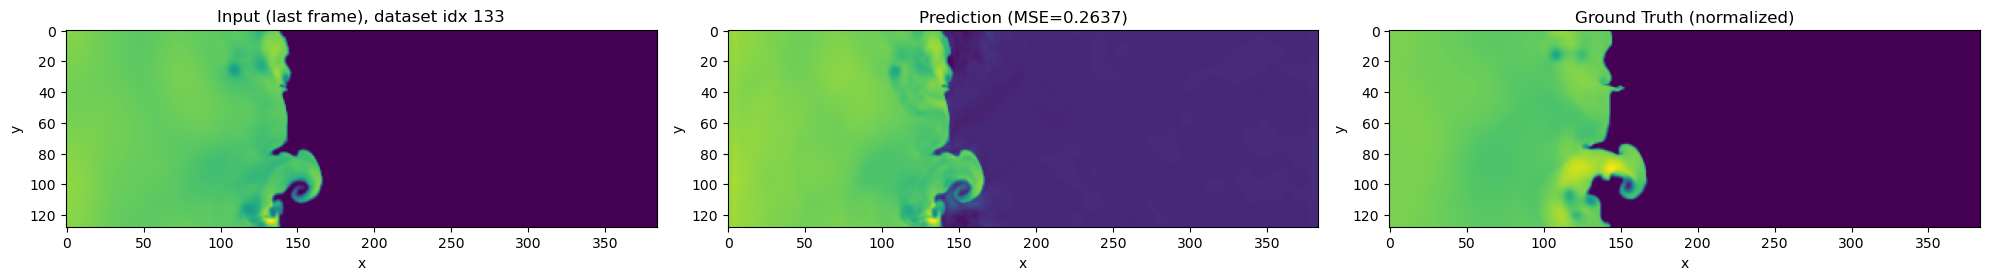

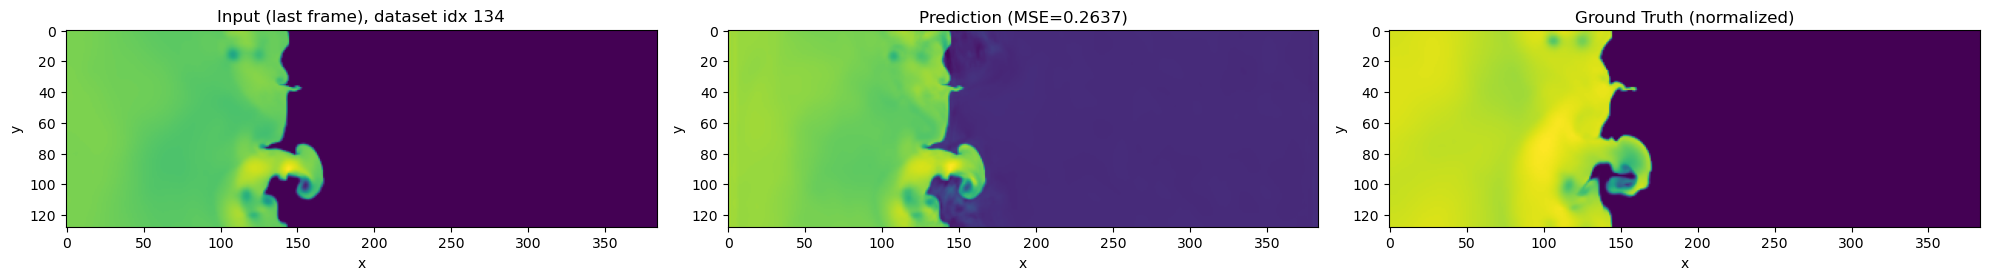

In [22]:
# Visualize a sample prediction with correct dataset alignment
# n_frames = 4, Ntrain = 100 assumed from earlier cells
n_frames = 4  # adjust if changed elsewhere
Ntrain = 100  # adjust if changed elsewhere

for i in range(30, 32):
    # For test sample i, the corresponding dataset index is:
    dataset_idx = Ntrain + i + n_frames - 1
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))
    # Show the last input frame (the 4th frame in the window)
    input_last_frame = X_test[i][-4:][0].numpy()  # channel 0 of last frame
    axes[0].imshow(input_last_frame)
    axes[0].set_title(f'Input (last frame), dataset idx {dataset_idx}')
   
    # Show the normalized ground truth used for training
    axes[2].imshow(y_test[i][0].numpy())
    axes[2].set_title('Ground Truth (normalized)')
    # Show the model prediction
    axes[1].imshow(test_pred[i, 0].numpy())
    axes[1].set_title(f'Prediction (MSE={test_mse:.4f})')
    for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

Even after implementing gradient loss, changing the kernel size from 3 -> 5 (second nearest neigbor) and introducing extra loss terms from edge recognition, we  find that significant improvements in MSE, but the model still diffuses out and doesn't make an expressive and physical prediction. Let's compare these results with the baseline model: the same CNN but without cyclic padding to enforce the translational equivariance in the y-direction:

In [ ]:
# Train the CNN model with regular padding as a baseline comparison.
from torch.utils.data import TensorDataset, DataLoader

# No need to unsqueeze, already (N, 4, H, W)
X_train_c = X_train
y_train_c = y_train
X_test_c = X_test
y_test_c = y_test

# Define a CNN that uses all 4 input channels and predicts all 4 output channels
class RegularPadCNN(nn.Module):
    def __init__(self):
        super().__init__()
        kernel_size=5
        self.conv1 = CircPadConv2d(4, 16, kernel_size=kernel_size) # Layer 1: 4 input channels, 16 output channels
        self.conv2 = CircPadConv2d(16, 32, kernel_size=kernel_size) # Layer 2: 16 input channels, 32 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 3: 32 input channels, 16 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 4: 32 input channels, 16 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 5: 32 input channels, 16 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 6: 32 input channels, 16 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 7: 32 input channels, 16 output channels
        self.conv3 = CircPadConv2d(32, 16, kernel_size=kernel_size) # Layer 8: 32 input channels, 16 output channels
        self.conv4 = CircPadConv2d(16, 4, kernel_size=kernel_size)  # Layer 9: 16 input channels, 4 output channels
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.relu(self.conv3(x))
        x = self.conv4(x)
        return x
# Let's introduce a gradient loss to encourage the model to learn the sharp boundary of the dense and dilute phases:
# This, turns out, to have massive improvement on the test MSE. 
def gradient_loss(pred, target):
    pred_dx = pred[:, :, :, 1:] - pred[:, :, :, :-1]
    target_dx = target[:, :, :, 1:] - target[:, :, :, :-1]
    pred_dy = pred[:, :, 1:, :] - pred[:, :, :-1, :]
    target_dy = target[:, :, 1:, :] - target[:, :, :-1, :]
    return ((pred_dx - target_dx).abs().mean() + (pred_dy - target_dy).abs().mean())


# Let's also add an edge loss to further encourage the model to capture the edges of the dense and dilute phases:
def sobel_edges(x):
    # x: (batch, channels, H, W)
    channels = x.shape[1]
    sobel_x = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=x.dtype, device=x.device).view(1,1,3,3).repeat(channels,1,1,1)
    sobel_y = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=x.dtype, device=x.device).view(1,1,3,3).repeat(channels,1,1,1)
    gx = F.conv2d(x, sobel_x, padding=1, groups=channels)
    gy = F.conv2d(x, sobel_y, padding=1, groups=channels)
    return torch.sqrt(gx**2 + gy**2)

def edge_loss(pred, target):
    pred_edges = sobel_edges(pred)
    target_edges = sobel_edges(target)
    return (pred_edges - target_edges).abs().mean()

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = RegularPadCNN().to(device)

# Training setup
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Training loop
n_epochs = 4
alpha = 0.1 # weight for edge loss
for epoch in range(n_epochs):
    model.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model(xb)
        loss = criterion(pred, yb) + 0.1 * gradient_loss(pred, yb)
        # loss =  mse_loss + alpha * edge_loss(pred, yb)
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)
    if (epoch + 1) % 2 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train MSE: {epoch_loss:.6f}')

# Evaluate on test set
model.eval()
with torch.no_grad():
    test_pred = model(X_test_c.to(device)).cpu()
    test_mse = criterion(test_pred, y_test_c).item()
print(f'\nTest MSE for no circular padding: {test_mse:.6f}')

Epoch 2/4  Train MSE: 62.001409
Epoch 4/4  Train MSE: 30.923314

Test MSE: 29.829750


NameError: name 'X_test' is not defined

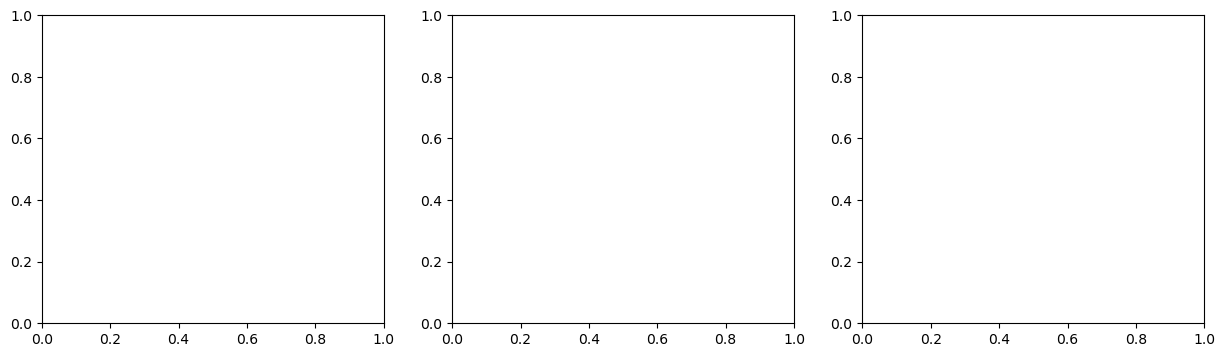

In [6]:
# Visualize a sample prediction

for i in range(50,53):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    sample_idx = i
    axes[0].imshow(X_test[sample_idx][0].numpy()); axes[0].set_title('Input')
    axes[1].imshow(y_test[sample_idx][0].numpy()); axes[1].set_title('Ground Truth')
    axes[2].imshow(test_pred[sample_idx, 0].numpy()); axes[2].set_title(f'Prediction (MSE={test_mse:.4f})')
    for ax in axes: ax.set_xlabel('x'); ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

We find, as expected, that the regular CNN achieves the same performance as the one with cyclic padding. If the model is not able to express the physics in the system, it wouldn't make sense that it would have an impact on the performance if we turn the symmetry-preserving constraint on or off. 

Let's now try the FNO model that is used in the_well tutorial:

In [25]:
from neuralop.models import FNO

# --- Lightweight Model ---
class ResidualFNO(nn.Module):
    def __init__(self):
        super().__init__()
        self.fno = FNO(
            n_modes=(8, 8),       # fewer modes
            in_channels=16,
            out_channels=4,
            hidden_channels=32,   # small
            n_layers=3,           # fewer layers
            domain_padding=0.0,   # skip padding overhead
        )

    def forward(self, x):
        last_frame = x[:, -4:, :, :]
        correction = self.fno(x)
        return last_frame + correction

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model_fno = ResidualFNO().to(device)
print(f"FNO parameters: {sum(p.numel() for p in model_fno.parameters()):,}")

# --- Training setup ---
optimizer = torch.optim.Adam(model_fno.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_dataset = TensorDataset(X_train_c, y_train_c)
train_loader = DataLoader(train_dataset, batch_size=8, shuffle=True)

# --- Training loop (fewer epochs, no gradient loss) ---
n_epochs = 10
for epoch in range(n_epochs):
    model_fno.train()
    epoch_loss = 0.0
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        pred = model_fno(xb)
        loss = criterion(pred, yb)  # just MSE, skip gradient_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * xb.size(0)
    epoch_loss /= len(train_dataset)

    if (epoch + 1) % 1 == 0:
        print(f'Epoch {epoch+1}/{n_epochs}  Train loss: {epoch_loss:.6f}')

# --- Final evaluation ---
model_fno.eval()
with torch.no_grad():
    preds = []
    for i in range(0, len(X_test_c), 8):
        xb = X_test_c[i:i+8].to(device)
        preds.append(model_fno(xb).cpu())
    test_pred_fno = torch.cat(preds)
    test_mse_fno = criterion(test_pred_fno, y_test_c).item()

# Denormalize
test_pred_fno_phys = test_pred_fno * output_std + output_mean
y_test_phys = y_test_c * output_std + output_mean

print(f'\n--- FNO Results ---')
print(f'Test MSE (normalized): {test_mse_fno:.6f}')

print(f'\nPer-field VRMSE:')
for f in range(4):
    field_var = y_test_phys[:, f].var()
    field_mse = (test_pred_fno_phys[:, f] - y_test_phys[:, f]).pow(2).mean()
    vrmse = (field_mse / field_var).sqrt()
    print(f'  Field {f}: {vrmse:.4f}')

FNO parameters: 135,028
Epoch 1/10  Train loss: 0.353080
Epoch 2/10  Train loss: 0.285991
Epoch 3/10  Train loss: 0.249180
Epoch 4/10  Train loss: 0.231958
Epoch 5/10  Train loss: 0.221127
Epoch 6/10  Train loss: 0.210704
Epoch 7/10  Train loss: 0.203861
Epoch 8/10  Train loss: 0.198312
Epoch 9/10  Train loss: 0.192977
Epoch 10/10  Train loss: 0.187923

--- FNO Results ---
Test MSE (normalized): 0.208083

Per-field VRMSE:
  Field 0: 0.2639
  Field 1: 0.6006
  Field 2: 0.5132
  Field 3: 0.4612


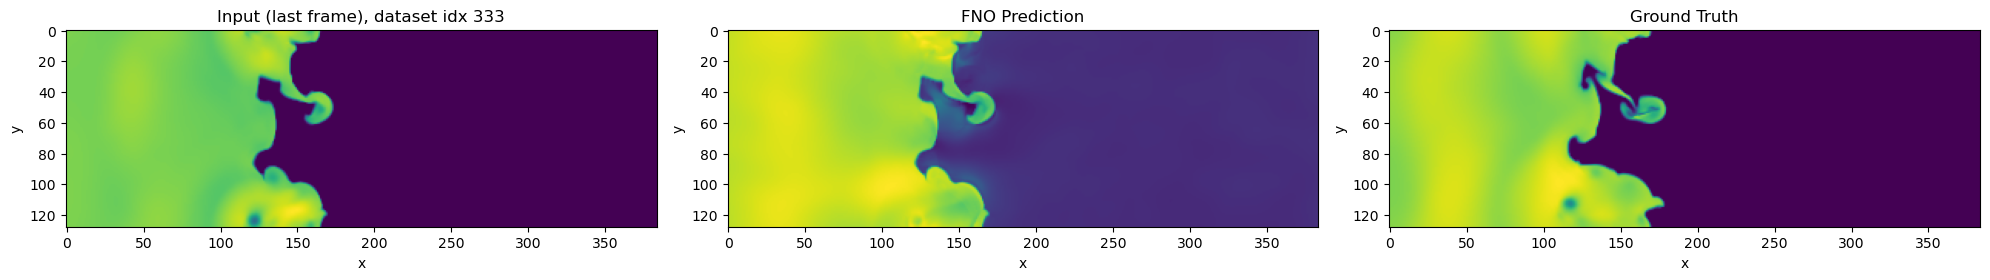

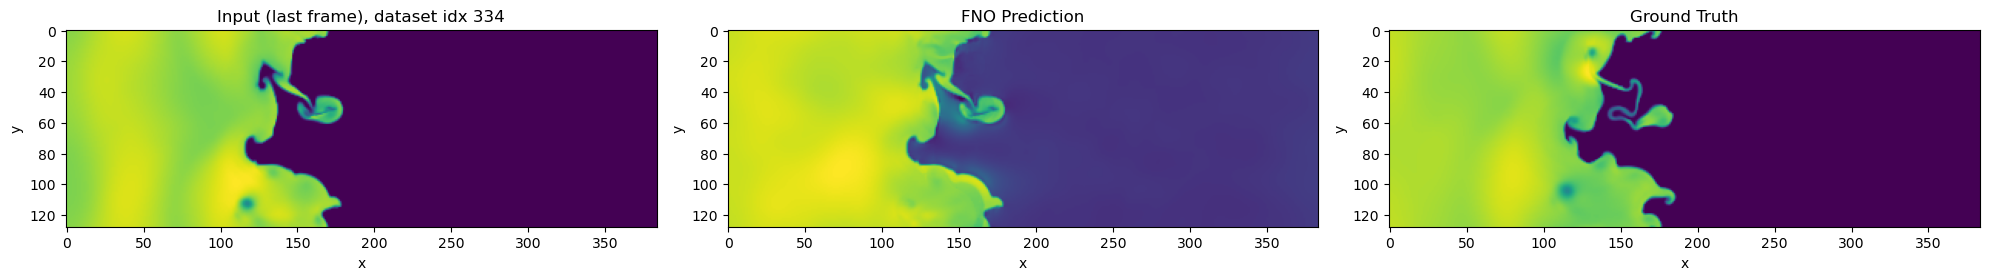

In [26]:
# Visualize FNO predictions (denormalized to physical units)
n_frames = 4
Ntrain = 300  # adjust to match your setup

for i in range(30, 32):
    dataset_idx = Ntrain + i + n_frames - 1
    fig, axes = plt.subplots(1, 3, figsize=(20, 4))

    # Last input frame (physical units) — channel 0 (density)
    input_last_frame = X_test[i][-4:][0].numpy()
    axes[0].imshow(input_last_frame)
    axes[0].set_title(f'Input (last frame), dataset idx {dataset_idx}')

    # FNO prediction (denormalized)
    axes[1].imshow(test_pred_fno_phys[i, 0].numpy())
    axes[1].set_title(f'FNO Prediction')

    # Ground truth (denormalized)
    axes[2].imshow(y_test_phys[i, 0].numpy())
    axes[2].set_title('Ground Truth')

    for ax in axes:
        ax.set_xlabel('x')
        ax.set_ylabel('y')
    plt.tight_layout()
    plt.show()

In [ ]:
# GPU Test cell

import torch
print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"CUDA version: {torch.version.cuda}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"GPU memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch version: 2.5.1+cu121
CUDA available: True
CUDA version: 12.1
GPU: NVIDIA GeForce RTX 4070
GPU memory: 12.9 GB
